In [12]:
!pip uninstall -y numpy
!pip install gensim --no-cache-dir
!pip install numpy==1.23.5

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 239.2 MB/s eta 0:00:00
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
xarray 2025.1.2 requires numpy>=1

***IMPORT THƯ VIỆN***

In [1]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords

# Nếu chưa cài nltk thì thực hiện download các gói cần thiết
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

***TIỀN XỬ LÍ DỮ LIỆU***

In [2]:
# clean dữ liệu
from bs4 import BeautifulSoup
def clean_text(text):
    text = BeautifulSoup(text, "lxml").text
    text = re.sub(r'\|\|\|', r' ', text)
    text = re.sub(r'http\S+', r'<URL>', text)
    text = text.lower()
    text = text.replace('x', '')
    text = re.sub(r'\d+', '', text)  # loại bỏ số
    text = re.sub(r'[^\w\s]', '', text)  # loại bỏ dấu câu
    text = re.sub(r'\s+', ' ', text).strip() # Loại bỏ khoảng trắng thừa
    return text

# Tokenize
def tokenize_text(text):
    tokens = []
    for sent in nltk.sent_tokenize(text):
        for word in nltk.word_tokenize(sent):
            if len(word) < 2:
                continue
            tokens.append(word.lower())
    return tokens

# Hàm xử lý và trả về chuỗi văn bản đã làm sạch (vì Vectorizer cần đầu vào là string)
def process_text_str(text):
    tokens = process_text(text)
    return ' '.join(tokens)


***HÀM XỬ LÍ DỮ LIỆU***

In [3]:
# Hàm xử lí dữ liệu
def process_text(text):
    text = clean_text(text)
    tokens = tokenize_text(text)
    return tokens

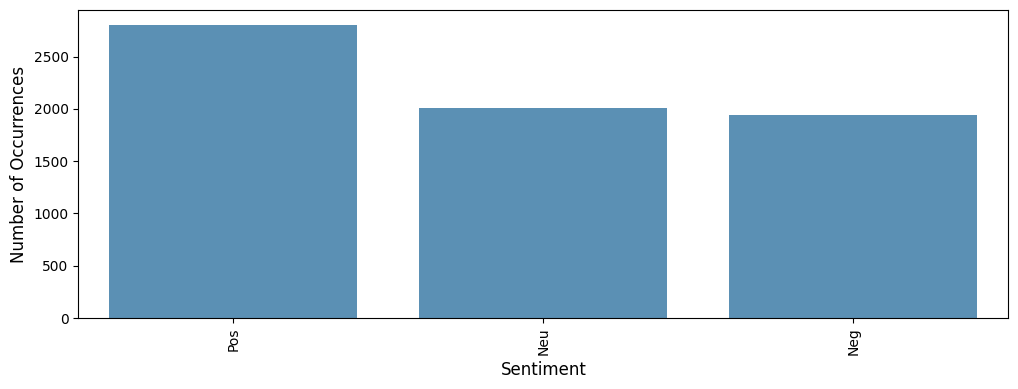

In [4]:
# Đọc file data
df = pd.read_csv("data.csv")
# Áp dụng tiền xử lý cho cột bình luận
df['clean_comment'] = df['Comment_raw'].apply(process_text_str)

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn import utils
from sklearn.linear_model import LogisticRegression
import numpy as np

cnt_pro = df['Sentiment'].value_counts()
plt.figure(figsize=(12,4))
sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.xticks(rotation=90)
plt.show();

In [5]:
def print_data(index):
    example = df[df.index == index][['Comment_raw', 'Sentiment']].values[0]
    if len(example) > 0:
        print(example[0])
        print('Sentiment:', example[1])
print_data(120)


train, test = train_test_split(df, test_size=0.3, random_state=42)

train_tagged = train.apply(
    lambda r: TaggedDocument(words=tokenize_text(r['clean_comment']), tags=[str(r.Sentiment)]), axis=1)

test_tagged = test.apply(
    lambda r: TaggedDocument(words=tokenize_text(r['clean_comment']), tags=[str(r.Sentiment)]), axis=1)

train_tagged.values[4]

Âm thanh quá hỗn độn, như bị đánh bại bởi cơn bão không thương tiếc.
Sentiment: Neg


TaggedDocument(words=['yeees', 'frogs', 'thing', 'thing', 'money', 'coins', 'is', 'fallen', 'from', 'sky', 'tomorrow', 'go', 'for', 'shoppingeven', 'now', 'my', 'son', 'already', 'having', 'fun', 'drinking', 'soda', 'out', 'side', 'door', 'celebrating'], tags=['Neu'])

In [6]:
import multiprocessing
cores = multiprocessing.cpu_count()

def vec_for_learning(model, tagged_docs):
    sents = tagged_docs.values
    targets, regressors = zip(
        *[(doc.tags[0], model.infer_vector(doc.words, epochs=20)) for doc in sents]
    )
    return targets, regressors

logreg = LogisticRegression(n_jobs=1, C=1e5, max_iter=1000)

from sklearn.metrics import accuracy_score, f1_score

model_dmm = Doc2Vec(dm=1, dm_mean=1, vector_size=300, window=10, negative=5, min_count=1, workers=5, alpha=0.065, min_alpha=0.065)
model_dmm.build_vocab([x for x in tqdm(train_tagged.values)])

100%|██████████| 4729/4729 [00:00<00:00, 1137189.75it/s]


In [7]:
%%time
initial_alpha = 0.065
min_alpha = 0.001
alpha_decay = (initial_alpha - min_alpha) / 30  # Tính toán mức giảm hợp lý

for epoch in range(30):
    model_dmm.train(utils.shuffle([x for x in tqdm(train_tagged.values)]), total_examples=len(train_tagged.values), epochs=1)
    model_dmm.alpha = max(model_dmm.alpha - alpha_decay, min_alpha)  # Không giảm quá mức
    model_dmm.min_alpha = model_dmm.alpha


100%|██████████| 4729/4729 [00:00<00:00, 1849921.99it/s]


CPU times: user 19.9 s, sys: 3.38 s, total: 23.3 s
Wall time: 19.1 s


In [8]:
y_train, X_train = vec_for_learning(model_dmm, train_tagged)
y_test, X_test = vec_for_learning(model_dmm, test_tagged)

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print('Testing accuracy %s' % accuracy_score(y_test, y_pred))
print('Testing F1 score: {}'.format(f1_score(y_test, y_pred, average='weighted')))

Testing accuracy 0.6201282683769117
Testing F1 score: 0.6181901592660489


In [9]:
def predict_new_text(new_text, model_dmm, classifier):
    words = new_text.split()
    vec_dmm = model_dmm.infer_vector(words, epochs=20)

    # In ra vector đặc trưng của văn bản
    print("Vector representation:", vec_dmm)

    return classifier.predict([vec_dmm])[0]

new_text = "ai chê chứ tui thấy hay mà"
predicted_label = predict_new_text(new_text, model_dmm, logreg)
print("Predicted Product:", predicted_label)

Vector representation: [-1.40576568e-02  5.00604976e-04  1.73067150e-03 -7.95150269e-03
 -6.77222246e-03  8.63399263e-03 -6.05519256e-03 -8.01911019e-03
  5.74475806e-03 -1.03593548e-03  4.31025168e-03 -3.04118992e-04
  1.00367405e-02 -7.15554852e-05 -7.05538830e-03 -1.21167675e-02
  2.83846492e-03 -4.29171196e-04  6.24822127e-03  3.29326792e-03
  4.84248716e-03 -3.66690825e-03  1.18548321e-02  2.89756083e-03
  5.38425811e-04 -2.30949977e-03  1.56445801e-03  7.90198334e-03
 -3.04215332e-03 -7.54489424e-03 -1.68529793e-03  2.85874959e-03
 -8.67532380e-03 -5.89087419e-03  2.84113875e-03 -2.27524992e-03
  4.05037450e-03 -6.54577604e-03  3.33538884e-03  5.31125255e-03
  4.48674010e-03  8.22765939e-03 -8.88151862e-03 -1.07176807e-02
 -6.96799811e-03 -8.26309901e-03  7.25146849e-03 -2.00602901e-03
 -1.80239975e-03  5.39759733e-03 -3.86777753e-03 -2.46057892e-03
  1.62028370e-03 -9.25567746e-03  7.98940286e-03  1.17688510e-03
 -1.33545604e-03  3.58480564e-03 -9.80869588e-03 -4.24926955e-04
  